In [17]:
from tqdm import tqdm
import os

# filename = "data/tsp/tsp10-200_concorde.txt"
# filename = "data/tsp/tsp10-200_omer_test_2.txt"
filename = "data/tsp/tsp10-200_cnocorde_with_a_100.2.txt"


# Get the total number of lines in the file without iteration
with open(filename, "r") as file:
    total_lines = sum(1 for _ in file)

print(f"Total lines in the file: {total_lines}")


Total lines in the file: 25600


In [18]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    def __repr__(self):
        return f"({self.x}, {self.y})"
    
    def distance(self, other):
        return ((self.x - other.x) ** 2 + (self.y - other.y) ** 2) ** 0.5

In [19]:
import pandas as pd

num_nodes_col = []
tour_length_col = []

offset = 1280 * 0

# for line in open(filename, "r").readlines()[offset:(offset + 1280)]:
for line in open(filename, "r").readlines():
    line = line.split(" ")
    num_nodes = int(line.index('output') // 2)
    cities_points = [Point(float(line[idx]), float(line[idx + 1])) for idx in range(0, 2 * num_nodes, 2)]
    tour_nodes = [int(node) - 1 for node in line[line.index('output') + 1:-1]]

    tour_length = sum(
        cities_points[tour_nodes[i]].distance(cities_points[tour_nodes[i + 1]])
        for i in range(len(tour_nodes) - 1)
    )
    
    num_nodes_col.append(num_nodes)
    tour_length_col.append(tour_length)


base_df = pd.DataFrame({
    "num_nodes": num_nodes_col,
    "tour_length": tour_length_col,
})
base_df

,num_nodes,tour_length
0,10,313.724362
1,10,270.217060
2,10,384.441124
3,10,317.375601
4,10,323.490178
...,...,...
25595,200,1491.932360
25596,200,1521.377849
25597,200,1629.356142
25598,200,1475.229500


In [20]:
# # # df.apply(lambda row: df[df.tour_length <= row['tour_length']].count(), axis=1)

# total_samples_with_num_nodes = []
# lower_equal_tour_lengths_counts = []

# grouped_counts = base_df.groupby("num_nodes").count()

# for index, row in base_df.iterrows():
#     # Count the number of rows with tour_length less than or equal to the current row's tour_length
#     upper_limit = row.iloc[1]
#     num_nodes = row.iloc[0]

#     total_num_nodes = grouped_counts.loc[num_nodes, 'tour_length']
#     count = base_df[(base_df.num_nodes == num_nodes) & (base_df.tour_length <= upper_limit)].count().iloc[0]

#     total_samples_with_num_nodes.append(total_num_nodes)
#     lower_equal_tour_lengths_counts.append(count)

# # lower_equal_tour_lengths_counts

# df_with_counts = pd.concat([
#     base_df, 
#     pd.Series(lower_equal_tour_lengths_counts, name='lower_equal_tour_lengths_counts'),
#     pd.Series(total_samples_with_num_nodes, name='total_samples_with_num_nodes')
#     ],
#     axis=1
# )

# df_with_counts

In [21]:
# df_with_probs = pd.concat([
#     df_with_counts,
#     pd.Series(
#         [count / total for count, total in zip(lower_equal_tour_lengths_counts, total_samples_with_num_nodes)],
#         name='probability'
#     ),
# ], axis=1)

# df_with_probs

In [22]:
import math


# square_size = 1
square_size = 100 ** 2
control_parameter = base_df.apply(
    lambda row: row['tour_length'] / math.sqrt(row["num_nodes"] * square_size),
    axis=1
)

df_with_control_parameter = pd.concat([
    base_df,
    pd.Series(control_parameter, name='control_parameter'),
], axis=1)

df_with_control_parameter

,num_nodes,tour_length,control_parameter
0,10,313.724362,0.992084
1,10,270.217060,0.854501
2,10,384.441124,1.215710
3,10,317.375601,1.003630
4,10,323.490178,1.022966
...,...,...,...
25595,200,1491.932360,1.054955
25596,200,1521.377849,1.075777
25597,200,1629.356142,1.152129
25598,200,1475.229500,1.043145


In [23]:
hard_instances = df_with_control_parameter[
    (df_with_control_parameter["control_parameter"] >= 0.75 ) &
    (df_with_control_parameter["control_parameter"] <= 0.77)
]

hard_instances
# hard_instances.sort_values(by="num_nodes", ascending=True, inplace=False)
# hard_instances.index
# hard_instances.num_nodes.value_counts()


,num_nodes,tour_length,control_parameter
14,10,239.401826,0.757055
44,10,238.739815,0.754962
51,10,240.415447,0.760260
59,10,240.699227,0.761158
69,10,240.239680,0.759705
82,10,240.887193,0.761752
129,10,242.240962,0.766033
194,10,240.288772,0.759860
205,10,237.496667,0.751030
221,10,241.000111,0.762109


In [24]:
from pandas import Series, DataFrame
import pandas as pd

def generate_batches_from_df_subset_by_num_nodes(df, batch_size=16):
    result_df = DataFrame()
    count_of_num_nodes: Series = df.num_nodes.value_counts()

    for num_nodes, count in count_of_num_nodes.items():
        number_of_rows_to_take = (count // batch_size) * batch_size
        if number_of_rows_to_take < batch_size:
            continue

        df_subset = df[df.num_nodes == num_nodes].iloc[:number_of_rows_to_take]
        result_df = pd.concat([result_df, df_subset], ignore_index=False)
    
    return result_df
    
hard_instances_batches = generate_batches_from_df_subset_by_num_nodes(hard_instances, batch_size=16)
hard_instances_batches

,num_nodes,tour_length,control_parameter
14,10,239.401826,0.757055
44,10,238.739815,0.754962
51,10,240.415447,0.760260
59,10,240.699227,0.761158
69,10,240.239680,0.759705
82,10,240.887193,0.761752
129,10,242.240962,0.766033
194,10,240.288772,0.759860
205,10,237.496667,0.751030
221,10,241.000111,0.762109


In [25]:

def generate_dataset_file_by_index(original_dataset_file, indices, output_file):
    original_dataset_lines = open(original_dataset_file, "r").readlines()

    with open(output_file, "w") as out_file:
        for idx in tqdm(indices, desc="Writing to output file"):
            out_file.write(original_dataset_lines[idx])

output_filename = "data/tsp/hard_tsp10-200_concorde.txt"
generate_dataset_file_by_index(filename, hard_instances_batches.index, output_filename)

Writing to output file: 100%|██████████| 32/32 [00:00<?, ?it/s]


In [26]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# probabilities  = df_with_probs['probability'].values
# # probabilities = np.random.rand(1280)  # Random probabilities between 0 and 1


# # Create bins and labels
# bins = np.arange(0, 1.1, 0.1)  # [0.0, 0.1, ..., 1.0]
# labels = [f'{round(bins[i], 1)}–{round(bins[i+1], 1)}' for i in range(len(bins)-1)]

# # Bin the data
# binned_probabilities = pd.cut(probabilities, bins=bins, labels=labels, include_lowest=True)

# # Create a DataFrame for plotting
# df = pd.DataFrame({'Probability Range': binned_probabilities})

# # Plot using seaborn
# plt.figure(figsize=(10, 6))
# sns.countplot(data=df, x='Probability Range', order=labels, palette='viridis')
# plt.title('Probability Distribution Across Bins')
# plt.xlabel('Probability Range')
# plt.ylabel('Count')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()
# # df.value_counts()

C:\Users\omers\AppData\Local\Temp\ipykernel_32064\3870060669.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')


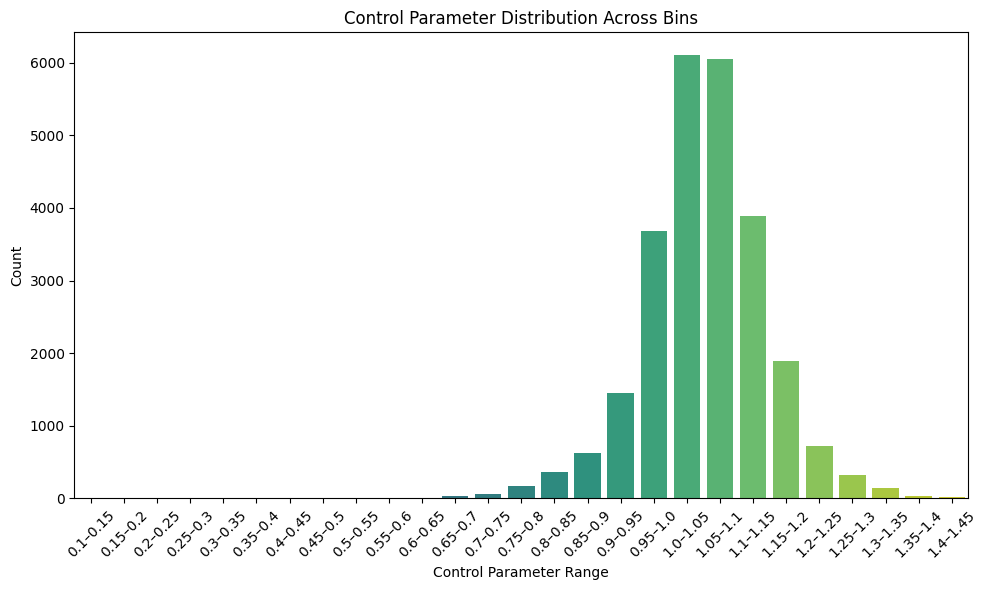

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

control_parameters  = df_with_control_parameter['control_parameter'].values
# probabilities = np.random.rand(1280)  # Random probabilities between 0 and 1


# Create bins and labels
# bins = np.arange(0.7, 1.0, 0.01)
bins = np.arange(0.1, 1.5, 0.05)
labels = [f'{round(bins[i], 2)}–{round(bins[i+1], 2)}' for i in range(len(bins)-1)]

# Bin the data
binned_control_parameters = pd.cut(control_parameters, bins=bins, labels=labels, include_lowest=True)

# Create a DataFrame for plotting
df = pd.DataFrame({'Control Parameter Range': binned_control_parameters})

# Plot using seabornon
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Control Parameter Range', order=labels, palette='viridis')
plt.title('Control Parameter Distribution Across Bins')
plt.xlabel('Control Parameter Range')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# df.value_counts()